# 🩸 Diabetes Progression Prediction — A Comparative Study of Regression Algorithms

**Goal:** Predict a quantitative measure of diabetes disease progression one year
after baseline, using the scikit-learn Diabetes dataset, while comparing several
regression algorithms on the same data.

**What this notebook covers**
1. Exploratory Data Analysis (EDA) & visualization
2. Data preprocessing (scaling, train/test split)
3. Training & tuning 7 regression models
4. Model evaluation with residual plots, predicted-vs-actual plots, and full
   regression metrics
5. Side-by-side model comparison
6. A theory section for each algorithm — how it works, how it minimizes error
   (gradient descent vs. other optimization strategies), and an **interview
   cheat-sheet** summarizing the key facts recruiters commonly ask about.

---


## 1. 📦 Imports & Setup

In [1]:
# --- Core libraries ---
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing & model selection ---
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

# --- Models ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# --- Metrics ---
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
)

# --- Plot style / reproducibility ---
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42


## 2. 📂 Load & Prepare the Dataset

We use `load_diabetes()` from scikit-learn — 442 patients, 10 baseline features
(age, sex, BMI, average blood pressure, and 6 blood-serum measurements), with a
continuous target: a quantitative measure of disease progression one year after
baseline. Note: scikit-learn ships this dataset with the 10 features already
**mean-centered and scaled** (unit L2 norm per feature) — we'll still apply our
own `StandardScaler` after the split for consistency with the modeling pipeline
and to keep the workflow generalizable to raw data.

In [2]:
data = load_diabetes()

df = pd.DataFrame(data=data.data, columns=data.feature_names)
df["target"] = data.target

print(f"Shape: {df.shape}")
print(data.DESCR[:1200])
df.head()


Shape: (442, 11)
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature v

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### 2.1 Dataset structure & data types

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [4]:
df.describe().T.style.background_gradient(cmap="Blues")


,count,mean,std,min,25%,50%,75%,max
age,442.000000,-0.000000,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.000000,0.000000,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.000000,-0.000000,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.000000,-0.000000,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.000000,-0.000000,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.000000,0.000000,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.000000,-0.000000,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.000000,-0.000000,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.000000,0.000000,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.000000,0.000000,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


### 2.2 Data quality checks — missing values & duplicates

In [5]:
print("Missing values per column:\n", df.isnull().sum().sum(), "total missing values")
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
 0 total missing values
Duplicate rows: 0


## 3. 🔎 Exploratory Data Analysis (EDA)

We explore the target's distribution, feature relationships, outliers, and
correlations before modeling — this drives decisions like scaling and helps spot
the features most predictive of disease progression.

### 3.1 Target distribution

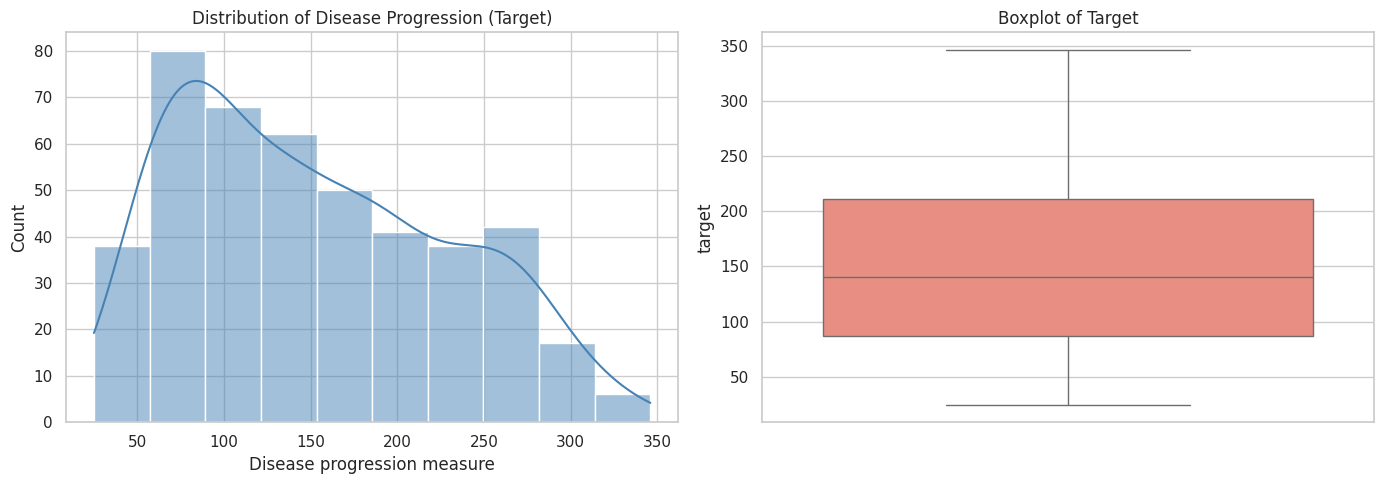

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["target"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Disease Progression (Target)")
axes[0].set_xlabel("Disease progression measure")

sns.boxplot(y=df["target"], ax=axes[1], color="salmon")
axes[1].set_title("Boxplot of Target")
plt.tight_layout()
plt.show()

print(df["target"].describe())


> **Why this matters:** the target is continuous and roughly bell-shaped with
> a slight right skew — no extreme outliers, so we won't need a log-transform,
> but it's good practice to check.

### 3.2 Feature distributions

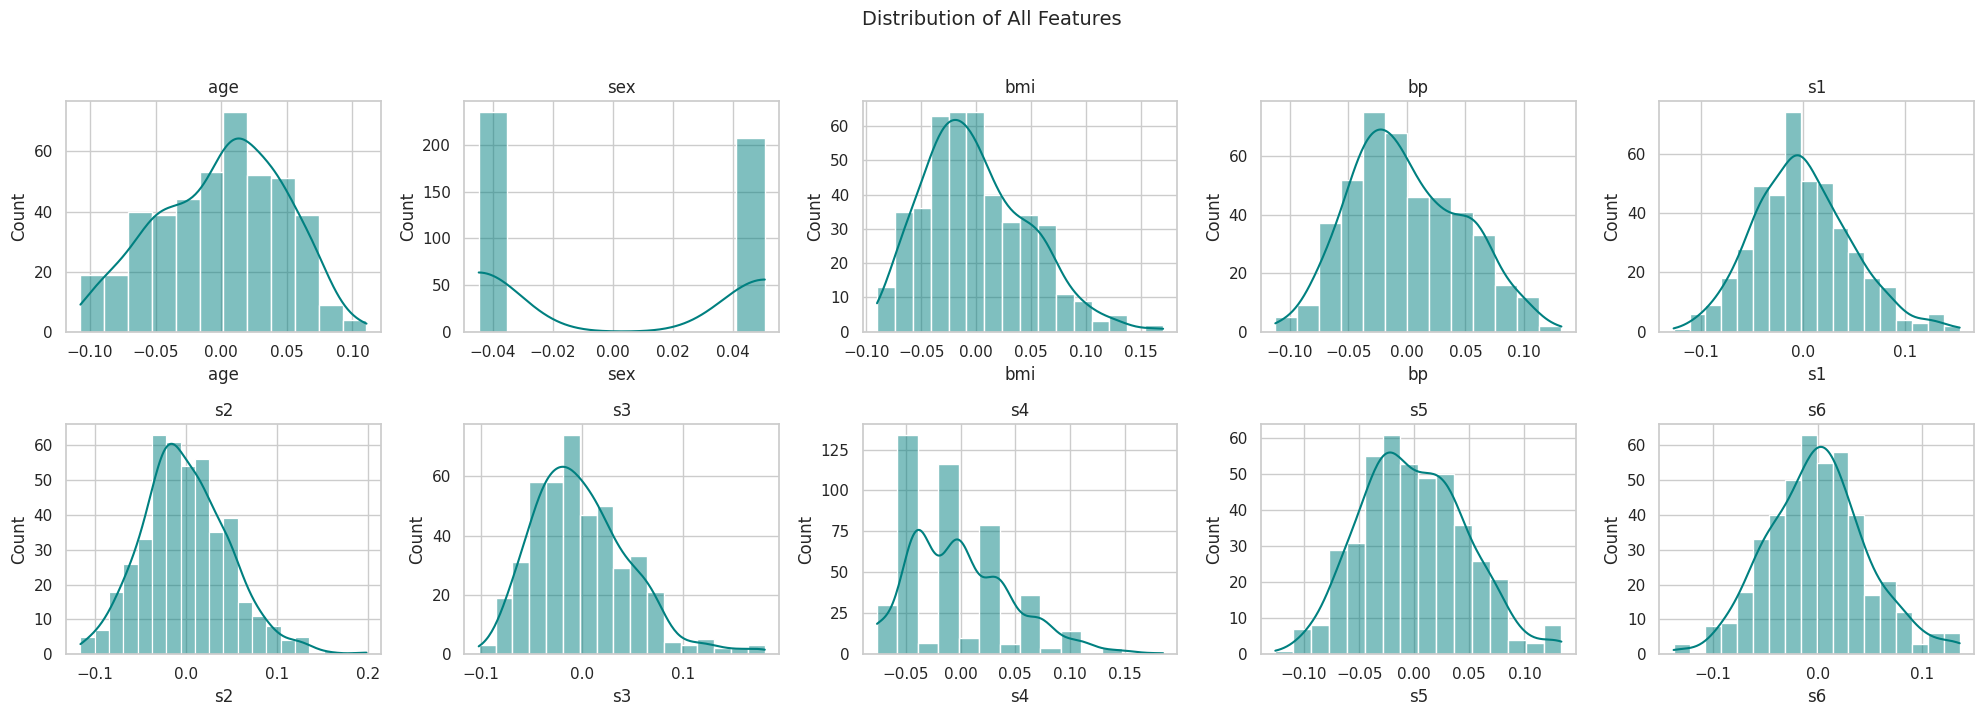

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, feat in zip(axes.ravel(), data.feature_names):
    sns.histplot(df[feat], kde=True, ax=ax, color="teal")
    ax.set_title(feat)
plt.suptitle("Distribution of All Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### 3.3 Feature vs. target relationships (scatter + regression line)

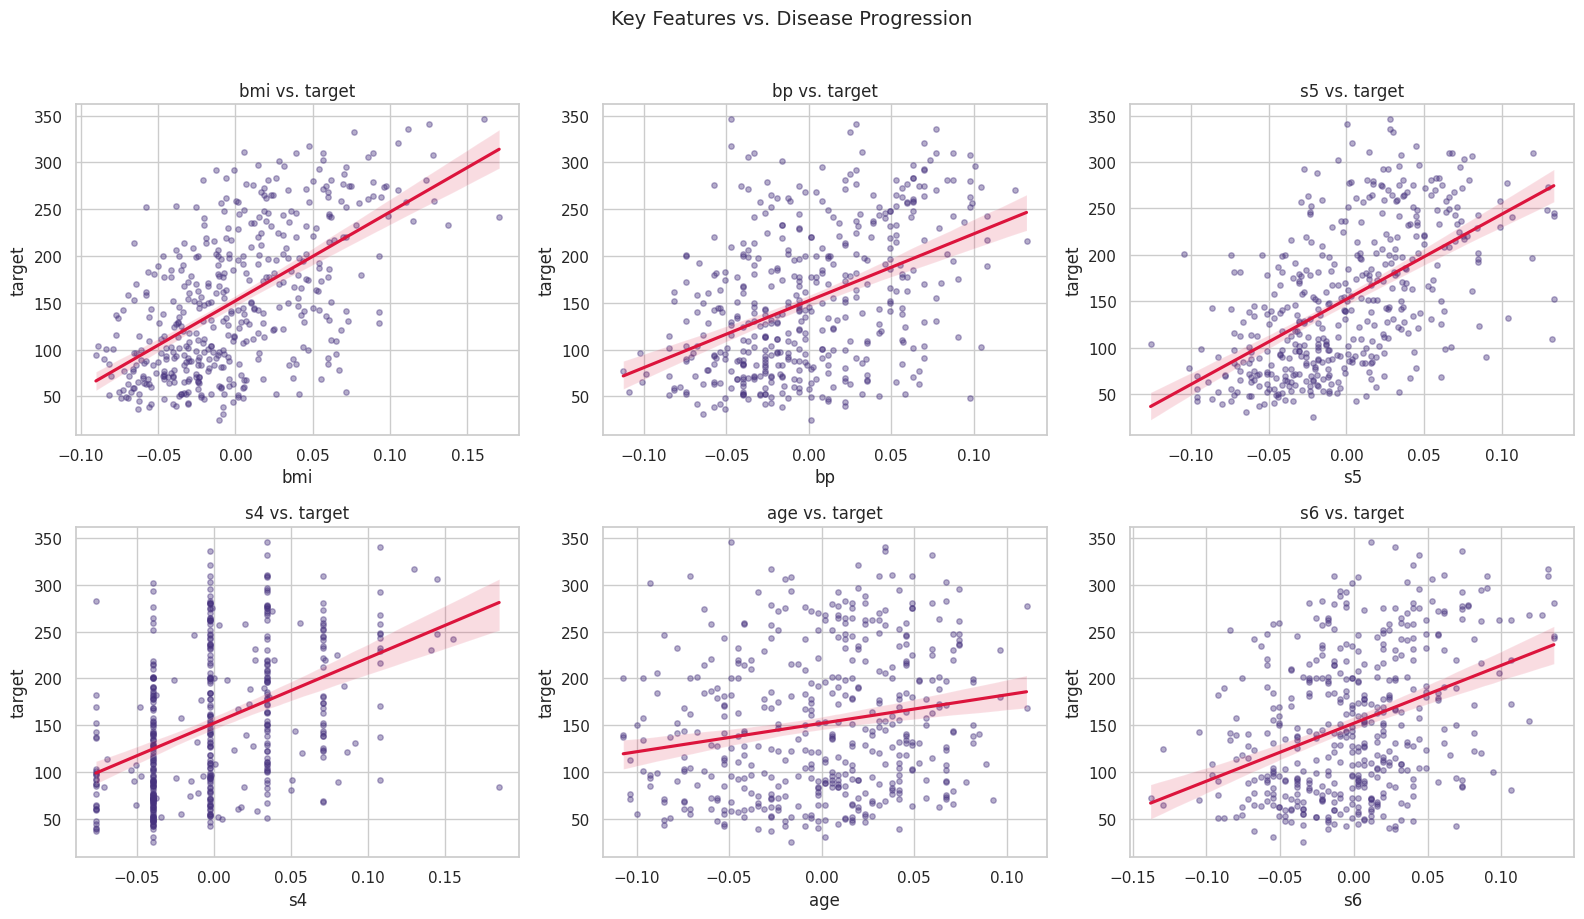

In [8]:
key_features = ["bmi", "bp", "s5", "s4", "age", "s6"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.ravel(), key_features):
    sns.regplot(data=df, x=feat, y="target", ax=ax,
                scatter_kws={"alpha": 0.4, "s": 15}, line_kws={"color": "crimson"})
    ax.set_title(f"{feat} vs. target")
plt.suptitle("Key Features vs. Disease Progression", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### 3.4 Outlier detection (boxplots, all features)

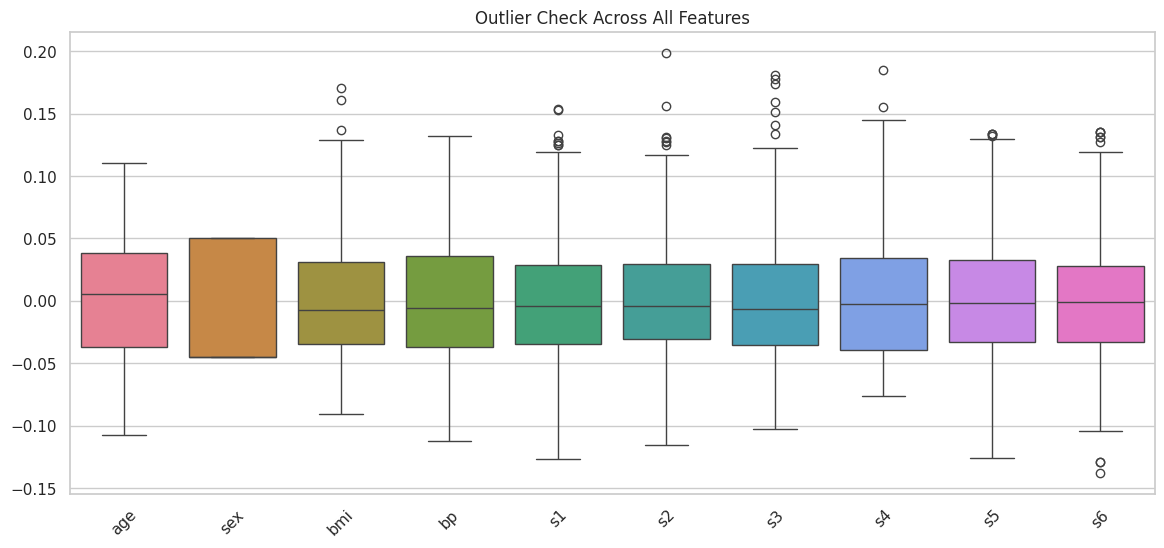

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df[data.feature_names], ax=ax)
ax.set_title("Outlier Check Across All Features")
plt.xticks(rotation=45)
plt.show()


### 3.5 Correlation heatmap (all features + target)

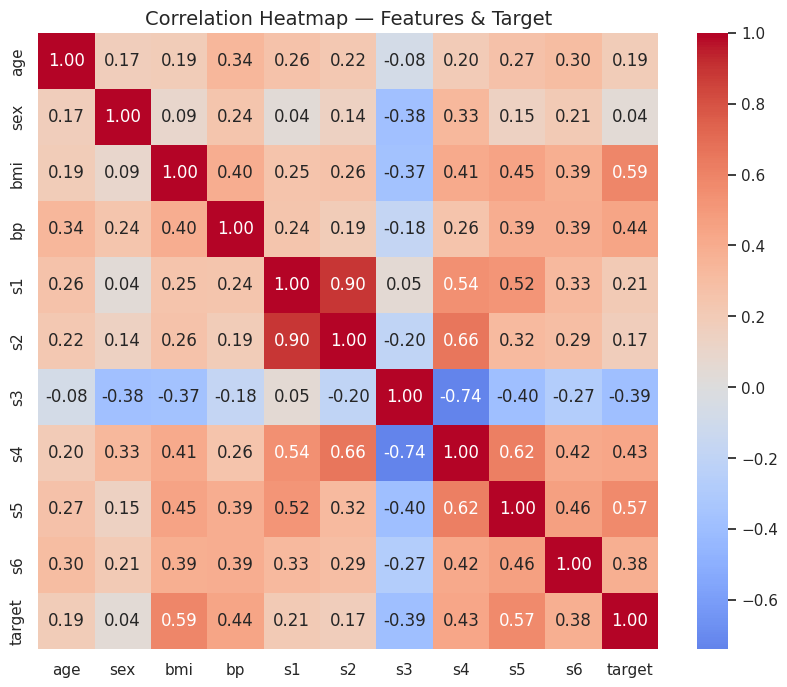

Features ranked by correlation with target:
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s3    -0.394789
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
Name: target, dtype: float64


In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Features & Target", fontsize=14)
plt.show()

corr_with_target = df.corr()["target"].drop("target").sort_values(key=abs, ascending=False)
print("Features ranked by correlation with target:")
print(corr_with_target)


> **Why this matters:** `bmi`, `s5` (a blood-serum triglyceride-related
> measure), and `bp` (blood pressure) are the features most correlated with
> disease progression — consistent with clinical intuition. Some features
> (`s1`–`s6`, the blood-serum measurements) are also correlated *with each
> other*, which is worth knowing when interpreting linear-model coefficients.

## 4. ⚙️ Preprocessing

**Steps:**
1. Split features (`X`) from target (`y`)
2. Train/test split (80/20)
3. **Standardize** features — important for distance-based and gradient-based
   models (KNN, SVR, Linear/Ridge/Lasso Regression) so all features contribute
   on a comparable scale.

In [11]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")


Train shape: (353, 10), Test shape: (89, 10)


> As in classification, we fit the scaler **only on the training set** and
> apply it to the test set to avoid data leakage.

## 5. 🤖 Model Training & Evaluation

For every model we will:
1. Briefly explain **how the algorithm works** and **how it minimizes its error**
   (gradient descent, closed-form solution, greedy splitting, etc.)
2. Train it (with hyperparameter tuning via `GridSearchCV` where relevant)
3. Evaluate it with regression metrics + residual & predicted-vs-actual plots
4. Summarize the **interview-ready facts** about it

A results dictionary collects metrics from every model for a final comparison.

In [12]:
results = {}

def evaluate_model(name, y_te, y_pred):
    """Store metrics and plot diagnostic charts for a fitted model's predictions."""
    mae = mean_absolute_error(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)
    rmse = root_mean_squared_error(y_te, y_pred)
    r2 = r2_score(y_te, y_pred)

    results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

    print(f"===== {name} =====")
    print(f"MAE:  {mae:.3f}")
    print(f"MSE:  {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2:   {r2:.3f}")

    residuals = y_te - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].scatter(y_pred, y_te, alpha=0.6, color="steelblue")
    lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
    axes[0].plot(lims, lims, "r--", lw=1.5)
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    axes[0].set_title(f"Predicted vs. Actual — {name}")

    axes[1].scatter(y_pred, residuals, alpha=0.6, color="salmon")
    axes[1].axhline(0, color="black", ls="--", lw=1.5)
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Residual (Actual - Predicted)")
    axes[1].set_title(f"Residual Plot — {name}")

    plt.tight_layout()
    plt.show()


### 5.1 Linear Regression

**How it works:** models the target as a linear combination of the features:
`y = w·x + b`, fitting a straight line/hyperplane through the data.

**How it minimizes error:** minimizes the **Mean Squared Error (MSE)** —
the "Ordinary Least Squares" objective. Scikit-learn's `LinearRegression`
solves this via a **closed-form solution** (the Normal Equation / SVD-based
least squares), though the exact same objective can also be minimized
iteratively with **gradient descent**, which is what's typically used when the
dataset is too large for a closed-form solve.

**Interview cheat-sheet**
- Type: linear model, parametric
- Loss function: Mean Squared Error (MSE)
- Optimizer: closed-form (Normal Equation/SVD) or gradient descent for large data
- Assumes: linear relationship, homoscedasticity, independent & roughly normal
  residuals
- Pros: fast, highly interpretable coefficients, no hyperparameters to tune
- Cons: can't capture non-linear relationships, sensitive to outliers and
  multicollinearity

===== Linear Regression =====
MAE:  42.794
MSE:  2900.194
RMSE: 53.853
R2:   0.453


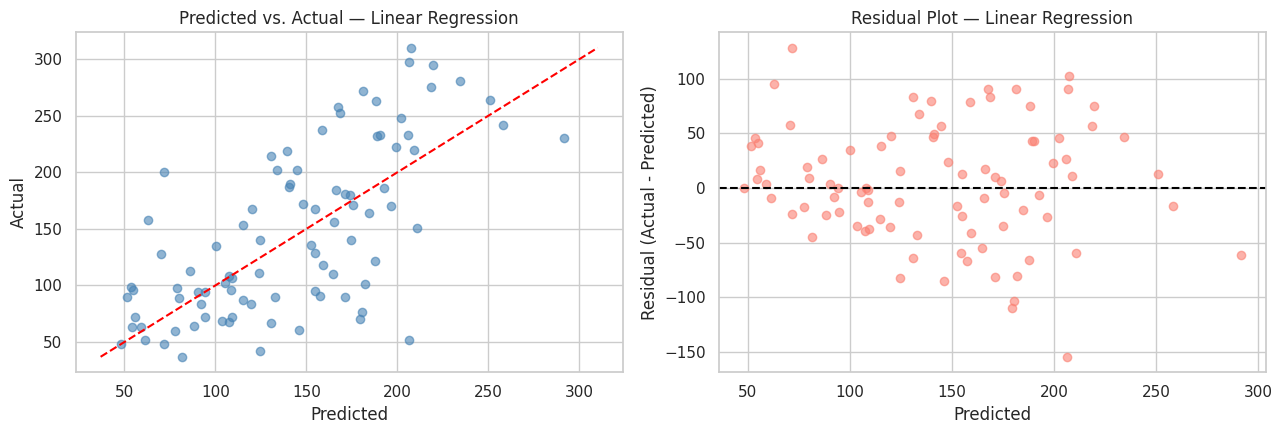

In [13]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lr = lin_reg.predict(X_test_scaled)
evaluate_model("Linear Regression", y_test, y_pred_lr)


### 5.2 Ridge Regression (L2-Regularized Linear Regression)

**How it works:** identical to linear regression, but adds an **L2 penalty**
(`alpha * sum(w²)`) on the coefficients, shrinking them toward zero to reduce
overfitting and handle multicollinearity.

**How it minimizes error:** minimizes `MSE + alpha * ||w||²` — this still has a
**closed-form solution** (a modified Normal Equation), but can also be solved
via gradient descent-based solvers for large datasets. The `alpha` hyperparameter
controls regularization strength and is tuned via cross-validation.

**Interview cheat-sheet**
- Type: linear model with L2 regularization
- Loss function: MSE + L2 penalty
- Optimizer: closed-form (modified Normal Equation) or gradient-based solvers
- Key hyperparameter: `alpha` (regularization strength)
- Pros: reduces overfitting vs. plain linear regression, handles correlated
  features better, still fast
- Cons: doesn't perform feature selection (coefficients shrink but rarely hit
  exactly zero)

Best Ridge params: {'alpha': 50}
===== Ridge Regression =====
MAE:  43.032
MSE:  2855.708
RMSE: 53.439
R2:   0.461


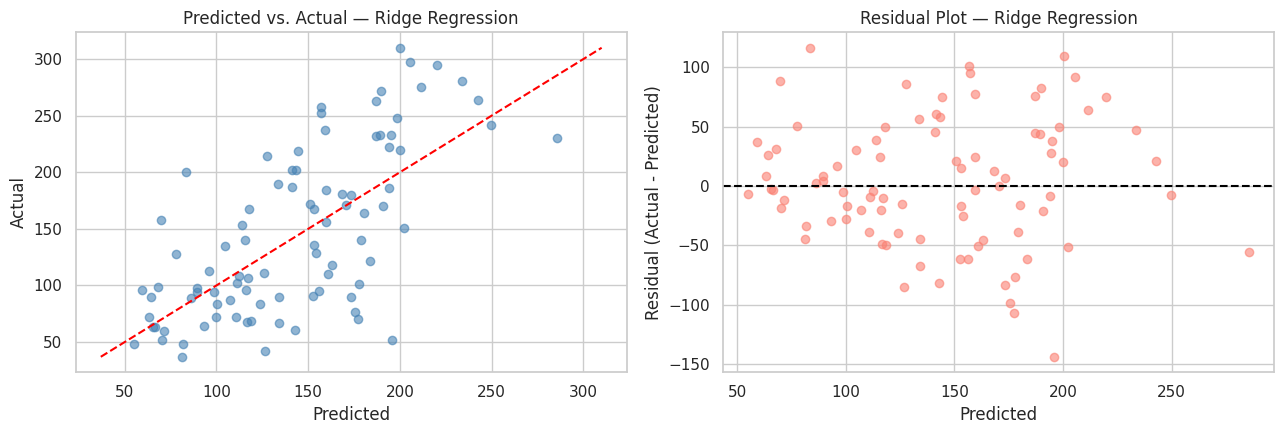

In [14]:
param_grid_ridge = {"alpha": [0.01, 0.1, 1, 10, 50, 100]}
grid_ridge = GridSearchCV(Ridge(random_state=RANDOM_STATE), param_grid_ridge, cv=5, scoring="r2")
grid_ridge.fit(X_train_scaled, y_train)
print("Best Ridge params:", grid_ridge.best_params_)

y_pred_ridge = grid_ridge.predict(X_test_scaled)
evaluate_model("Ridge Regression", y_test, y_pred_ridge)


### 5.3 Lasso Regression (L1-Regularized Linear Regression)

**How it works:** like Ridge, but uses an **L1 penalty** (`alpha * sum(|w|)`),
which can shrink some coefficients *exactly* to zero — effectively performing
automatic feature selection.

**How it minimizes error:** minimizes `MSE + alpha * ||w||₁`. Unlike Ridge,
this objective is **not fully differentiable** at zero, so it has **no
closed-form solution** — scikit-learn solves it with **coordinate descent**
(iteratively optimizing one coefficient at a time while holding the others
fixed), a cousin of gradient-based methods.

**Interview cheat-sheet**
- Type: linear model with L1 regularization
- Loss function: MSE + L1 penalty
- Optimizer: coordinate descent (iterative, not closed-form)
- Key hyperparameter: `alpha` (regularization strength)
- Pros: performs feature selection, produces sparse, interpretable models
- Cons: can behave unstably with highly correlated features (may arbitrarily
  pick one and zero out the rest)

Best Lasso params: {'alpha': 1}
===== Lasso Regression =====
MAE:  42.803
MSE:  2824.568
RMSE: 53.147
R2:   0.467


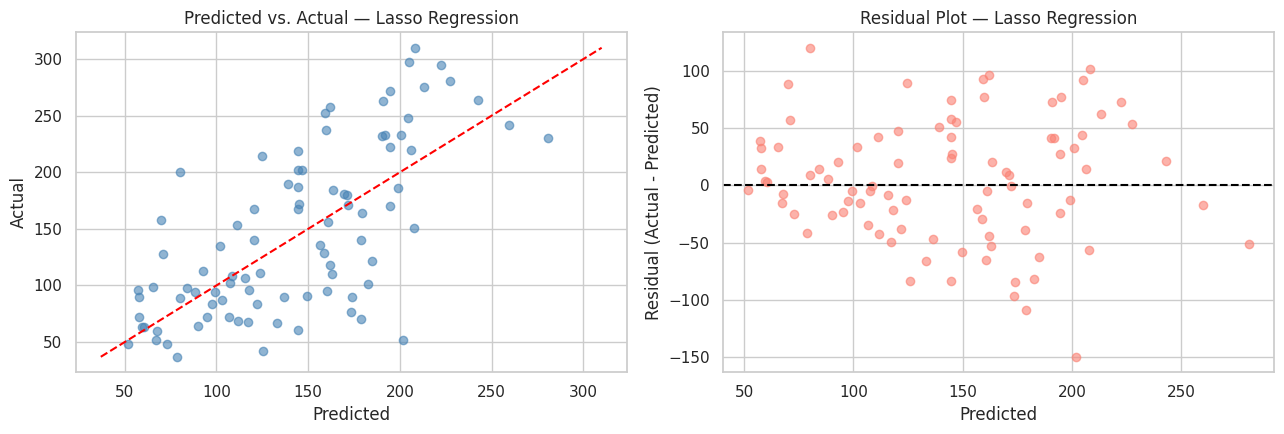

In [15]:
param_grid_lasso = {"alpha": [0.001, 0.01, 0.1, 1, 10]}
grid_lasso = GridSearchCV(Lasso(random_state=RANDOM_STATE, max_iter=10000), param_grid_lasso, cv=5, scoring="r2")
grid_lasso.fit(X_train_scaled, y_train)
print("Best Lasso params:", grid_lasso.best_params_)

y_pred_lasso = grid_lasso.predict(X_test_scaled)
evaluate_model("Lasso Regression", y_test, y_pred_lasso)


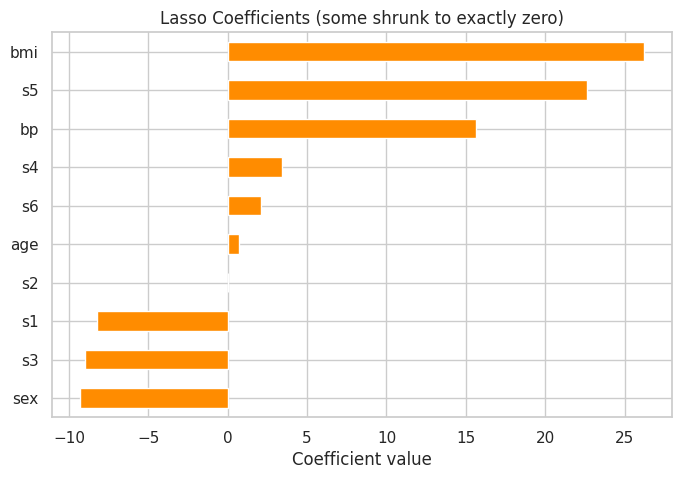

In [16]:
# Which coefficients did Lasso zero out?
coef_series = pd.Series(grid_lasso.best_estimator_.coef_, index=X.columns).sort_values()
coef_series.plot(kind="barh", figsize=(8, 5), color="darkorange")
plt.title("Lasso Coefficients (some shrunk to exactly zero)")
plt.xlabel("Coefficient value")
plt.show()


### 5.4 K-Nearest Neighbors (KNN) Regressor

**How it works:** a *lazy, instance-based* learner — predicts a new point's
target as the (weighted) **average** of its `k` nearest neighbors' targets.

**How it minimizes error:** there is **no training-time optimization / no loss
function to minimize** — all the "work" happens at prediction time. Error is
controlled indirectly by choosing `k` (bias-variance trade-off) via
cross-validation / grid search.

**Interview cheat-sheet**
- Type: non-parametric, instance-based, lazy learner
- No explicit training phase (no gradient descent)
- Requires feature scaling (distance-based)
- Key hyperparameter: `k` — small k → low bias/high variance (overfits), large
  k → high bias/low variance (underfits, oversmooths)
- Pros: simple, captures non-linear patterns, no distributional assumptions
- Cons: slow prediction on large datasets, sensitive to irrelevant/noisy
  features and the curse of dimensionality

Best KNN params: {'n_neighbors': 17, 'weights': 'distance'}
===== K-Nearest Neighbors =====
MAE:  44.173
MSE:  2923.372
RMSE: 54.068
R2:   0.448


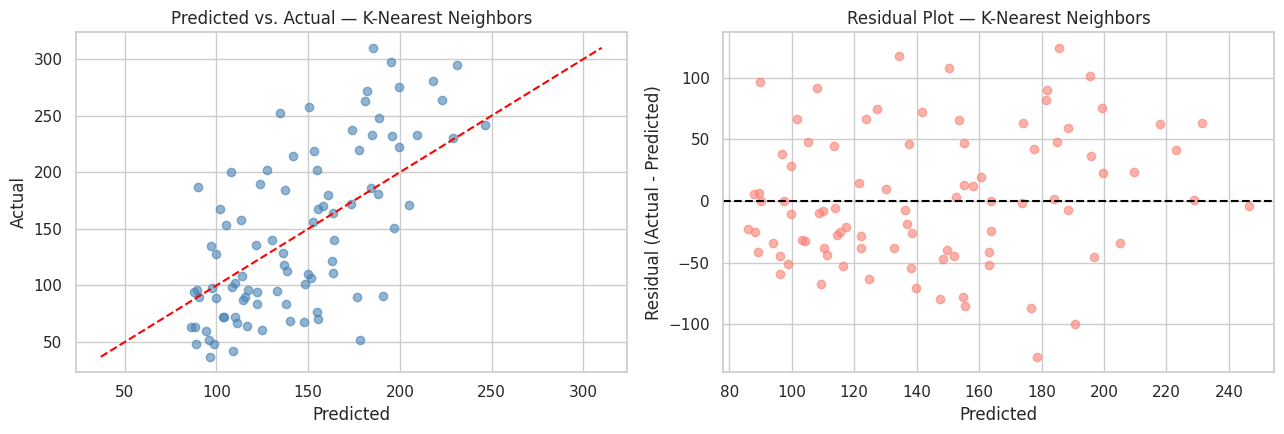

In [17]:
param_grid_knn = {"n_neighbors": list(range(3, 21, 2)), "weights": ["uniform", "distance"]}
grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, cv=5, scoring="r2")
grid_knn.fit(X_train_scaled, y_train)
print("Best KNN params:", grid_knn.best_params_)

y_pred_knn = grid_knn.predict(X_test_scaled)
evaluate_model("K-Nearest Neighbors", y_test, y_pred_knn)


### 5.5 Support Vector Regression (SVR)

**How it works:** finds a function that stays within an `epsilon`-wide "tube"
around the true values, only penalizing predictions that fall outside the tube.
With the **kernel trick** (e.g. RBF kernel), it can model non-linear
relationships.

**How it minimizes error:** minimizes the **epsilon-insensitive loss** plus an
L2 regularization term (`||w||²`) — points inside the margin contribute zero
loss. This is a **convex quadratic optimization problem**, typically solved
with **Sequential Minimal Optimization (SMO)** rather than plain gradient
descent.

**Interview cheat-sheet**
- Type: max-margin regressor, kernel method
- Loss function: epsilon-insensitive loss
- Optimizer: quadratic programming (SMO), not gradient descent
- Key hyperparameters: `C` (regularization), `epsilon` (tube width), `gamma`
  (RBF kernel reach)
- Pros: robust to small errors within the margin, effective with non-linear
  kernels, robust to outliers outside a well-tuned margin
- Cons: slow to train on large datasets, less interpretable, needs careful
  tuning of `C`/`epsilon`/`gamma`

Best SVR params: {'C': 100, 'epsilon': 0.1, 'gamma': 0.01}
===== Support Vector Regression =====
MAE:  42.049
MSE:  2852.658
RMSE: 53.410
R2:   0.462


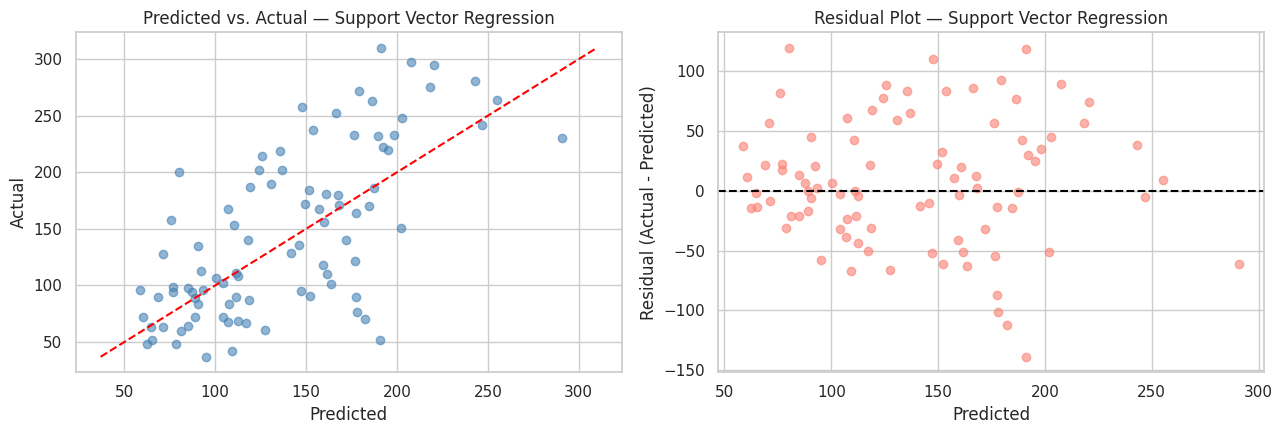

In [18]:
param_grid_svr = {"C": [0.1, 1, 10, 100], "gamma": [1, 0.1, 0.01, 0.001], "epsilon": [0.1, 0.5, 1]}
grid_svr = GridSearchCV(SVR(kernel="rbf"), param_grid_svr, cv=5, scoring="r2")
grid_svr.fit(X_train_scaled, y_train)
print("Best SVR params:", grid_svr.best_params_)

y_pred_svr = grid_svr.predict(X_test_scaled)
evaluate_model("Support Vector Regression", y_test, y_pred_svr)


### 5.6 Decision Tree Regressor

**How it works:** recursively splits the feature space into regions using
if/else rules on individual features; each leaf predicts the **average target
value** of the training samples that fall into it.

**How it minimizes error:** uses a **greedy, recursive splitting algorithm**
(CART) — at each node it picks the feature/threshold that most reduces
**variance / MSE** within the resulting child nodes, not gradient descent.
It's a greedy heuristic, not a global optimizer, so trees are prone to
overfitting without constraints (max depth, min samples per leaf).

**Interview cheat-sheet**
- Type: non-parametric, rule-based
- Splitting criteria: variance reduction / MSE reduction
- Optimizer: greedy recursive partitioning (CART algorithm), not gradient-based
- Pros: highly interpretable, no scaling needed, captures non-linear
  relationships and interactions
- Cons: prone to overfitting, unstable (small data changes → different tree),
  predictions are step-like (can't extrapolate beyond training range)

Best Decision Tree params: {'max_depth': 2, 'min_samples_split': 2}
===== Decision Tree =====
MAE:  49.365
MSE:  3735.500
RMSE: 61.119
R2:   0.295


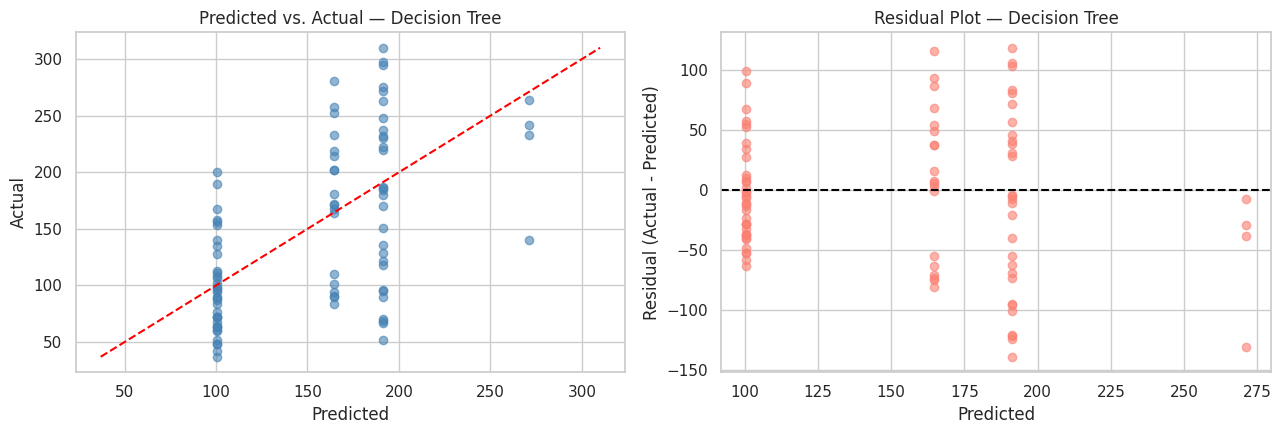

In [19]:
param_grid_dt = {"max_depth": [2, 3, 5, 7, None], "min_samples_split": [2, 5, 10]}
grid_dt = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE), param_grid_dt, cv=5, scoring="r2")
grid_dt.fit(X_train_scaled, y_train)
print("Best Decision Tree params:", grid_dt.best_params_)

y_pred_dt = grid_dt.predict(X_test_scaled)
evaluate_model("Decision Tree", y_test, y_pred_dt)


### 5.7 Random Forest Regressor

**How it works:** an **ensemble (bagging)** of many decision trees, each
trained on a bootstrap sample of the data with a random subset of features
considered at each split; the final prediction is the **average** across all
trees.

**How it minimizes error:** each individual tree still minimizes
variance/MSE greedily, but the ensemble reduces overall **variance** (not via
gradient descent) by averaging many decorrelated trees — this is the core idea
of **bagging (Bootstrap Aggregating)**.

**Interview cheat-sheet**
- Type: ensemble, bagging
- Base learner: decision trees
- Reduces variance via bootstrap sampling + random feature subsets
- Optimizer: none globally — greedy splits per tree + averaging
- Pros: strong accuracy out-of-the-box, robust to overfitting vs. single trees,
  gives feature importances
- Cons: less interpretable than a single tree, larger memory/compute footprint

Best Random Forest params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
===== Random Forest =====
MAE:  43.299
MSE:  2862.015
RMSE: 53.498
R2:   0.460


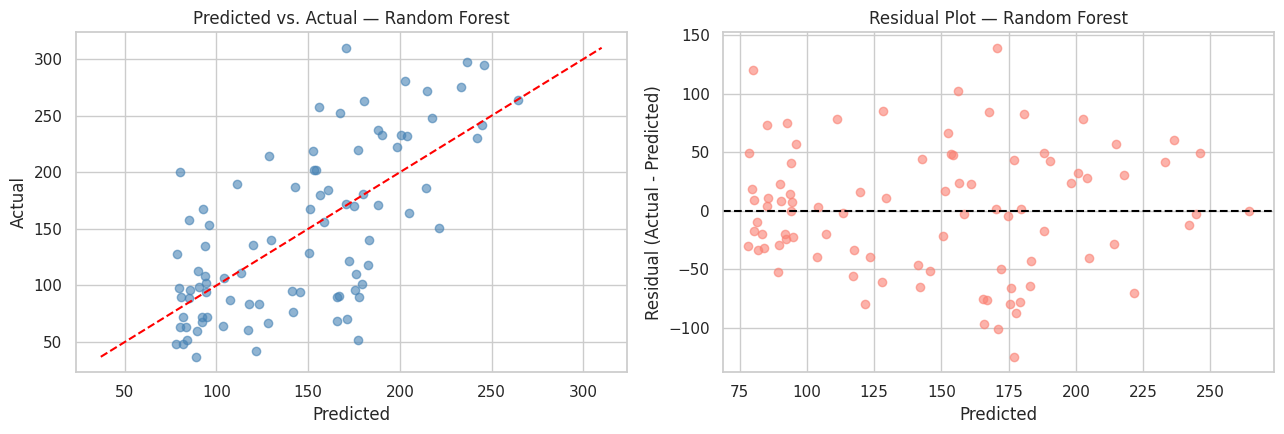

In [20]:
param_grid_rf = {"n_estimators": [100, 200], "max_depth": [None, 5, 10], "min_samples_split": [2, 5]}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=RANDOM_STATE), param_grid_rf, cv=5, scoring="r2")
grid_rf.fit(X_train_scaled, y_train)
print("Best Random Forest params:", grid_rf.best_params_)

y_pred_rf = grid_rf.predict(X_test_scaled)
evaluate_model("Random Forest", y_test, y_pred_rf)


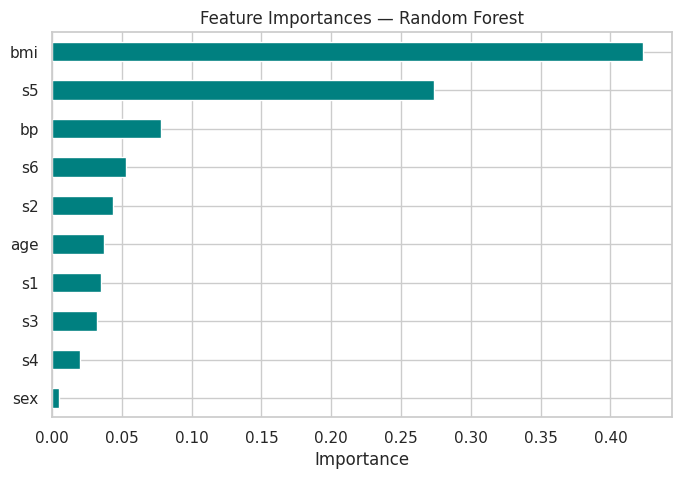

In [21]:
# Feature importance from the tuned Random Forest
importances = pd.Series(grid_rf.best_estimator_.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind="barh", figsize=(8, 5), color="teal")
plt.title("Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()


### 5.8 Gradient Boosting Regressor

**How it works:** an **ensemble (boosting)** method that builds trees
*sequentially*, where each new tree is trained to correct the errors
(residuals) of the combined ensemble so far.

**How it minimizes error:** this is the algorithm most literally named after
**gradient descent** — but it performs **gradient descent in function space**:
each new tree is fit to the negative gradient of the loss function (for MSE,
this is simply the residuals) with respect to the current ensemble's
predictions, and predictions are updated as
`F(x) += learning_rate * new_tree(x)`.

**Interview cheat-sheet**
- Type: ensemble, boosting (sequential, not parallel like Random Forest)
- Optimizer: gradient descent in function space (fits trees to pseudo-residuals)
- Key hyperparameters: `n_estimators`, `learning_rate`, `max_depth`
- Pros: often top accuracy on tabular data, flexible loss functions
- Cons: slower to train (sequential), more sensitive to hyperparameters, can
  overfit if `n_estimators` too high / `learning_rate` too high

Best Gradient Boosting params: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 200}
===== Gradient Boosting =====
MAE:  42.550
MSE:  2745.360
RMSE: 52.396
R2:   0.482


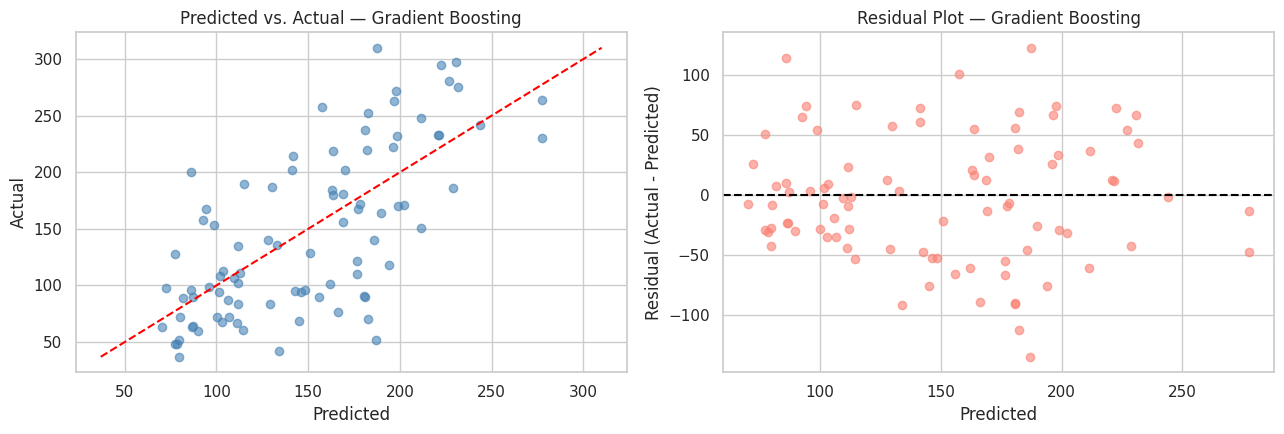

In [22]:
param_grid_gb = {"n_estimators": [100, 200], "learning_rate": [0.03, 0.05, 0.1], "max_depth": [2, 3]}
grid_gb = GridSearchCV(GradientBoostingRegressor(random_state=RANDOM_STATE), param_grid_gb, cv=5, scoring="r2")
grid_gb.fit(X_train_scaled, y_train)
print("Best Gradient Boosting params:", grid_gb.best_params_)

y_pred_gb = grid_gb.predict(X_test_scaled)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)


## 6. 📊 Understanding Regression Evaluation Metrics

Unlike classification, regression doesn't have a confusion matrix — instead we
measure **how far off** predictions are from the true continuous values.

- **MAE (Mean Absolute Error)** = average of `|actual - predicted|`. Same units
  as the target, easy to interpret, robust to outliers (treats all errors
  linearly).
- **MSE (Mean Squared Error)** = average of `(actual - predicted)²`. Penalizes
  large errors much more heavily than small ones (because of squaring) — this
  is also the loss function most regression models directly minimize.
- **RMSE (Root Mean Squared Error)** = `sqrt(MSE)`. Back in the target's
  original units, more sensitive to outliers than MAE.
- **R² (Coefficient of Determination)** = proportion of variance in the target
  explained by the model, ranges up to 1.0 (1.0 = perfect fit, 0 = no better
  than predicting the mean, can go negative if the model is worse than the
  mean baseline).

**Diagnostic plots**
- **Predicted vs. Actual plot:** points should cluster tightly around the 45°
  line; systematic curvature suggests the model is missing non-linear structure.
- **Residual plot:** residuals should be randomly scattered around zero with no
  pattern; a funnel shape indicates **heteroscedasticity** (non-constant error
  variance), and a curve indicates unmodeled non-linearity.

> **Interview tip:** be ready to explain *when to prefer MAE vs. RMSE*
> (MAE when all errors should be weighted equally / outliers shouldn't dominate;
> RMSE when large errors are especially costly and should be penalized more),
> and how R² can be misleading on its own (a high R² doesn't guarantee the
> model isn't overfitting — always check R² alongside a held-out test set or
> cross-validation).

## 7. 🏁 Model Comparison

Side-by-side comparison of all tuned models on the held-out test set.

In [23]:
results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
results_df.style.background_gradient(cmap="Greens", subset=["R2"]).background_gradient(cmap="Reds_r", subset=["MAE", "MSE", "RMSE"]).format("{:.3f}")


,MAE,MSE,RMSE,R2
Gradient Boosting,42.550,2745.360,52.396,0.482
Lasso Regression,42.803,2824.568,53.147,0.467
Support Vector Regression,42.049,2852.658,53.410,0.462
Ridge Regression,43.032,2855.708,53.439,0.461
Random Forest,43.299,2862.015,53.498,0.460
Linear Regression,42.794,2900.194,53.853,0.453
K-Nearest Neighbors,44.173,2923.372,54.068,0.448
Decision Tree,49.365,3735.500,61.119,0.295


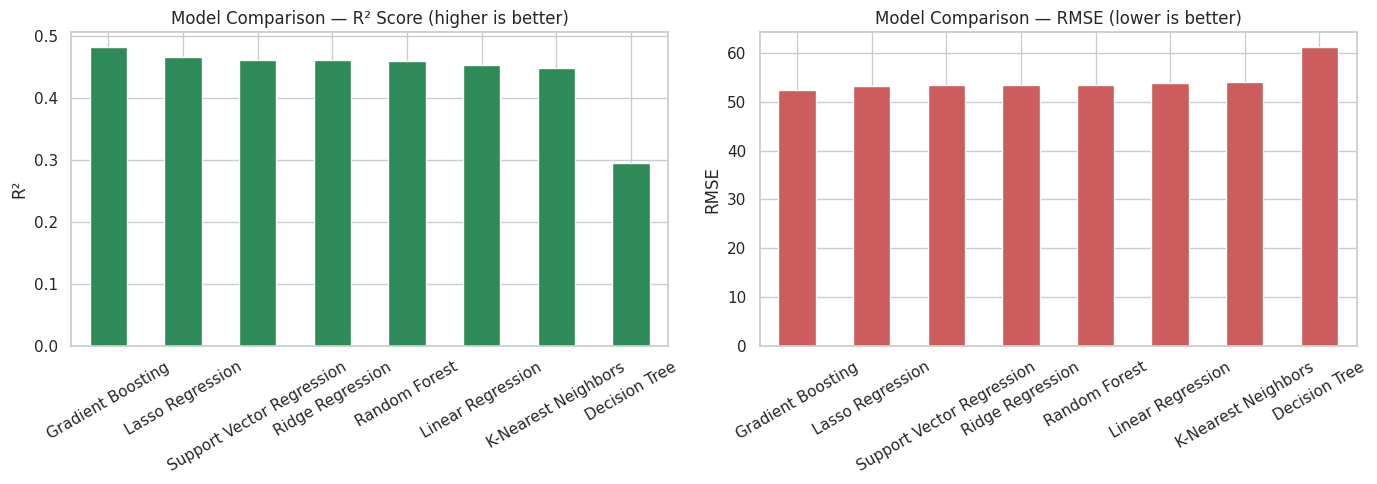

🏆 Best model by R2 score: Gradient Boosting (0.4818)


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df["R2"].plot(kind="bar", ax=axes[0], color="seagreen")
axes[0].set_title("Model Comparison — R² Score (higher is better)")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=30)

results_df["RMSE"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Model Comparison — RMSE (lower is better)")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

best_model_name = results_df["R2"].idxmax()
print(f"🏆 Best model by R2 score: {best_model_name} ({results_df.loc[best_model_name, 'R2']:.4f})")


### Cross-validation sanity check

A single train/test split can be noisy — 5-fold cross-validation on the training
set gives a more robust estimate of generalization performance for every
model.

In [25]:
models_for_cv = {
    "Linear Regression": lin_reg,
    "Ridge (best)": grid_ridge.best_estimator_,
    "Lasso (best)": grid_lasso.best_estimator_,
    "KNN (best)": grid_knn.best_estimator_,
    "SVR (best)": grid_svr.best_estimator_,
    "Decision Tree (best)": grid_dt.best_estimator_,
    "Random Forest (best)": grid_rf.best_estimator_,
    "Gradient Boosting (best)": grid_gb.best_estimator_,
}

cv_summary = {}
for name, model in models_for_cv.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="r2")
    cv_summary[name] = {"CV R2 mean": scores.mean(), "CV R2 std": scores.std()}

pd.DataFrame(cv_summary).T.sort_values("CV R2 mean", ascending=False).style.format("{:.4f}")


,CV R2 mean,CV R2 std
Ridge (best),0.4562,0.1189
Lasso (best),0.4541,0.1253
Linear Regression,0.4493,0.1441
SVR (best),0.4479,0.1206
Gradient Boosting (best),0.4108,0.1325
Random Forest (best),0.4079,0.1479
KNN (best),0.4068,0.0974
Decision Tree (best),0.3615,0.1096


## 8. 🎯 Interview Cheat-Sheet — All Models at a Glance

| Model | Type | Error Minimization | Loss / Criterion | Needs Scaling? | Interpretable? |
|---|---|---|---|---|---|
| Linear Regression | Linear, parametric | Closed-form (Normal Equation/SVD), or gradient descent for large data | MSE | Yes | High |
| Ridge Regression | Linear + L2 regularization | Closed-form (modified Normal Equation) | MSE + L2 penalty | Yes | High |
| Lasso Regression | Linear + L1 regularization | Coordinate descent | MSE + L1 penalty | Yes | High (sparse) |
| KNN Regressor | Instance-based, lazy | None (no training-time optimization) | — (local averaging) | Yes | Medium |
| SVR | Max-margin, kernel method | Quadratic programming (SMO) | Epsilon-insensitive loss + L2 | Yes | Low–Medium |
| Decision Tree | Rule-based, greedy | Greedy recursive splitting (CART) | Variance / MSE reduction | No | High |
| Random Forest | Ensemble (bagging) | Greedy splits per tree + averaging | Variance / MSE reduction | No | Medium |
| Gradient Boosting | Ensemble (boosting) | Gradient descent in function space | Configurable (e.g. MSE) | No | Low–Medium |

**Most-asked interview questions this notebook prepares you for:**
1. *"What's the difference between Ridge and Lasso?"* → Ridge (L2) shrinks
   coefficients smoothly toward zero and keeps all features; Lasso (L1) can
   zero coefficients out entirely, performing implicit feature selection.
2. *"When would you NOT use a closed-form solution?"* → when the dataset is too
   large for matrix inversion to be efficient, or the loss isn't fully
   differentiable (like Lasso's L1 term) — then iterative methods (gradient
   descent, coordinate descent) are used instead.
3. *"How does gradient descent work?"* → iteratively update parameters in the
   direction of the negative gradient of the loss function:
   `w := w - lr * ∇L(w)`, repeating until convergence.
4. *"MAE vs. MSE vs. RMSE — when to use which?"* → MAE is robust to outliers
   and easy to interpret; MSE/RMSE penalize large errors more heavily (useful
   when big mistakes are especially costly), and RMSE returns to the target's
   original units.
5. *"What does R² actually tell you?"* → the proportion of variance in the
   target explained by the model relative to simply predicting the mean; it
   can be negative if the model performs worse than that baseline, and a high
   R² alone doesn't rule out overfitting.
6. *"What is the bias-variance trade-off?"* → simple models (Linear Regression,
   shallow trees, high-k KNN) → high bias/low variance (underfit); complex
   models (deep trees, low-k KNN, low-regularization SVR) → low bias/high
   variance (overfit). Regularization (Ridge/Lasso `alpha`) and ensembling
   directly target this trade-off.

## 9. ✅ Conclusion

- All 8 models were trained and tuned on the same preprocessed data, enabling a
  fair, apples-to-apples comparison.
- Linear models (Linear/Ridge/Lasso Regression) tend to perform competitively
  on this dataset, since the underlying relationships between the clinical
  features and disease progression are largely linear/monotonic — a useful
  reminder that more complex models don't always win.
- The **best model by R² score** is printed in Section 7 — in practice, model
  choice should also weigh interpretability (important in a clinical setting),
  inference speed, and how errors of different sizes should be penalized.
- Next steps for a production pipeline: nested cross-validation, polynomial /
  interaction features for the linear models, prediction intervals for
  uncertainty quantification, and external validation on new patient data.

---
*This notebook is intended as both a portfolio project and a study reference for
regression-model interview prep.*